In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/dlp-26t2-week9-assignment/sample_submission.csv
/kaggle/input/competitions/dlp-26t2-week9-assignment/test/Image_0612.jpg
/kaggle/input/competitions/dlp-26t2-week9-assignment/test/Image_0946.jpg
/kaggle/input/competitions/dlp-26t2-week9-assignment/test/Image_0755.jpg
/kaggle/input/competitions/dlp-26t2-week9-assignment/test/Image_0178.jpg
/kaggle/input/competitions/dlp-26t2-week9-assignment/test/Image_1593.jpg
/kaggle/input/competitions/dlp-26t2-week9-assignment/test/Image_1975.jpg
/kaggle/input/competitions/dlp-26t2-week9-assignment/test/Image_0777.jpg
/kaggle/input/competitions/dlp-26t2-week9-assignment/test/Image_0998.jpg
/kaggle/input/competitions/dlp-26t2-week9-assignment/test/Image_0073.jpg
/kaggle/input/competitions/dlp-26t2-week9-assignment/test/Image_1769.jpg
/kaggle/input/competitions/dlp-26t2-week9-assignment/test/Image_0123.jpg
/kaggle/input/competitions/dlp-26t2-week9-assignment/test/Image_0770.jpg
/kaggle/input/competitions/dlp-26t2-week9-assignm

In [2]:
import os
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, random_split
from PIL import Image
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from tqdm import tqdm

torch.manual_seed(42)
np.random.seed(42)

# =========================================================
# CONFIG
# =========================================================
BASE_DIR = "/kaggle/input/competitions/dlp-26t2-week9-assignment"
TRAIN_DIR = f"{BASE_DIR}/train"
TEST_DIR = f"{BASE_DIR}/test"
IMG_SIZE = 128
BATCH_SIZE = 32
NUM_EPOCHS = 40          # kept moderate given your 2-day deadline
NUM_CLASSES = 10
LR = 1e-3

CLASS_MAP = {
    'Amphibia': 0, 'Animalia': 1, 'Arachnida': 2, 'Aves': 3, 'Fungi': 4,
    'Insecta': 5, 'Mammalia': 6, 'Mollusca': 7, 'Plantae': 8, 'Reptilia': 9
}
IDX_TO_CLASS = {v: k for k, v in CLASS_MAP.items()}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# =========================================================
# DATASET
# =========================================================
class FloraFaunaDataset(Dataset):
    def __init__(self, root_dir, class_map, transform=None):
        self.samples = []
        self.transform = transform
        self.class_map = class_map
        for cls_name, cls_idx in class_map.items():
            cls_dir = os.path.join(root_dir, cls_name)
            if not os.path.isdir(cls_dir):
                continue
            for fname in os.listdir(cls_dir):
                self.samples.append((os.path.join(cls_dir, fname), cls_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

class TestDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.files = sorted(os.listdir(root_dir))
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        img = Image.open(os.path.join(self.root_dir, fname)).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, fname

# =========================================================
# TRANSFORMS
# =========================================================
mean = [0.485, 0.456, 0.406]   # standard ImageNet-style normalization values
std = [0.229, 0.224, 0.225]    # (just normalization constants, not pretrained weights - fine to use)

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# =========================================================
# LOAD DATA + SPLIT
# =========================================================
full_dataset = FloraFaunaDataset(TRAIN_DIR, CLASS_MAP, transform=None)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_subset, val_subset = random_split(full_dataset, [train_size, val_size],
                                          generator=torch.Generator().manual_seed(42))

# Apply different transforms to train/val by wrapping
class TransformWrapper(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        img, label = self.subset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

full_dataset.transform = None  # raw PIL images from base dataset
train_dataset = TransformWrapper(train_subset, train_transform)
val_dataset = TransformWrapper(val_subset, eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))

# =========================================================
# MODEL: from-scratch ResNet-style CNN (random init, no pretrained weights)
# =========================================================
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += identity
        return self.relu(out)

class FromScratchResNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 48, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1)
        )
        self.layer1 = ResidualBlock(48, 64)
        self.layer2 = ResidualBlock(64, 128, stride=2)
        self.layer3 = ResidualBlock(128, 128)
        self.layer4 = ResidualBlock(128, 256, stride=2)
        self.layer5 = ResidualBlock(256, 256)

        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = self.global_pool(x).flatten(1)
        x = self.dropout(x)
        return self.fc(x)

model = FromScratchResNet(num_classes=NUM_CLASSES).to(device)
print(model)

# =========================================================
# LOSS / OPTIMIZER / SCHEDULER
# =========================================================
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6)

# =========================================================
# TRAIN / VALIDATE FUNCTIONS
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validating", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_f1 = f1_score(all_labels, all_preds, average='macro')
    return running_loss / total, correct / total, val_f1, all_preds, all_labels

# =========================================================
# TRAINING LOOP WITH EARLY STOPPING (based on val F1)
# =========================================================
best_f1 = 0.0
patience = 10
patience_counter = 0
save_path = "best_model.pth"

for epoch in range(1, NUM_EPOCHS + 1):
    start = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_f1, _, _ = validate(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    elapsed = time.time() - start
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch}/{NUM_EPOCHS} ({elapsed:.0f}s) | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_f1={val_f1:.4f} | lr={current_lr:.2e}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        patience_counter = 0
        torch.save(model.state_dict(), save_path)
        print(f"  -> New best F1: {best_f1:.4f}, model saved.")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch} (no F1 improvement for {patience} epochs).")
            break

# =========================================================
# LOAD BEST MODEL, FINAL VALIDATION REPORT
# =========================================================
model.load_state_dict(torch.load(save_path))
_, _, final_f1, all_preds, all_labels = validate(model, val_loader, criterion, device)
print(f"\nFinal best validation F1 (macro): {final_f1:.4f}")
print(classification_report(all_labels, all_preds, target_names=[IDX_TO_CLASS[i] for i in range(NUM_CLASSES)]))

# =========================================================
# INFERENCE ON TEST SET + SUBMISSION FILE
# =========================================================
test_dataset = TestDataset(TEST_DIR, transform=eval_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

model.eval()
image_ids, predictions = [], []
with torch.no_grad():
    for images, fnames in tqdm(test_loader, desc="Predicting test set"):
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        image_ids.extend([os.path.splitext(f)[0] for f in fnames])
        predictions.extend(preds.cpu().numpy())

submission = pd.DataFrame({"Image_ID": image_ids, "Label": predictions})
submission.to_csv("submission.csv", index=False)
print(submission.head())
print(f"\nSaved submission.csv with {len(submission)} predictions.")

Using device: cuda
Train samples: 7999
Val samples: 2000
FromScratchResNet(
  (stem): Sequential(
    (0): Conv2d(3, 48, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (layer1): ResidualBlock(
    (conv1): Conv2d(48, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (shortcut): Sequential(
      (0): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tru

Epoch 1/40 (91s) | train_loss=2.2895 train_acc=0.1916 | val_loss=2.2115 val_acc=0.2250 val_f1=0.1893 | lr=1.00e-03
  -> New best F1: 0.1893, model saved.


Epoch 2/40 (57s) | train_loss=2.1721 train_acc=0.2242 | val_loss=2.1534 val_acc=0.2335 val_f1=0.2063 | lr=1.00e-03
  -> New best F1: 0.2063, model saved.


Epoch 3/40 (57s) | train_loss=2.1438 train_acc=0.2398 | val_loss=2.1363 val_acc=0.2425 val_f1=0.2132 | lr=1.00e-03
  -> New best F1: 0.2132, model saved.


Epoch 4/40 (58s) | train_loss=2.1215 train_acc=0.2530 | val_loss=2.1208 val_acc=0.2550 val_f1=0.2354 | lr=1.00e-03
  -> New best F1: 0.2354, model saved.


...

Epoch 39/40 (57s) | train_loss=1.3426 train_acc=0.6400 | val_loss=1.7772 val_acc=0.4535 val_f1=0.4538 | lr=1.25e-04
  -> New best F1: 0.4538, model saved.


Epoch 40/40 (58s) | train_loss=1.3272 train_acc=0.6472 | val_loss=1.7867 val_acc=0.4375 val_f1=0.4389 | lr=1.25e-04



Final best validation F1 (macro): 0.4538
              precision    recall  f1-score   support

    Amphibia       0.38      0.36      0.37       228
    Animalia       0.42      0.44      0.43       204
   Arachnida       0.53      0.35      0.42       198
        Aves       0.59      0.52      0.55       216
       Fungi       0.52      0.54      0.53       194
     Insecta       0.40      0.44      0.42       190
    Mammalia       0.43      0.53      0.47       181
    Mollusca       0.40      0.39      0.39       192
     Plantae       0.62      0.56      0.59       213
    Reptilia       0.32      0.41      0.36       184

    accuracy                           0.45      2000
   macro avg       0.46      0.45      0.45      2000
weighted avg       0.46      0.45      0.46      2000



Predicting test set: 100%|██████████| 63/63 [00:18<00:00,  3.32it/s]

     Image_ID  Label
0  Image_0001      0
1  Image_0002      7
2  Image_0003      5
3  Image_0004      9
4  Image_0005      0

Saved submission.csv with 2000 predictions.


In [3]:
print(test_dataset.files[:5])
print(submission['Image_ID'][:5])

['Image_0001.jpg', 'Image_0002.jpg', 'Image_0003.jpg', 'Image_0004.jpg', 'Image_0005.jpg']
0    Image_0001
1    Image_0002
2    Image_0003
3    Image_0004
4    Image_0005
Name: Image_ID, dtype: object


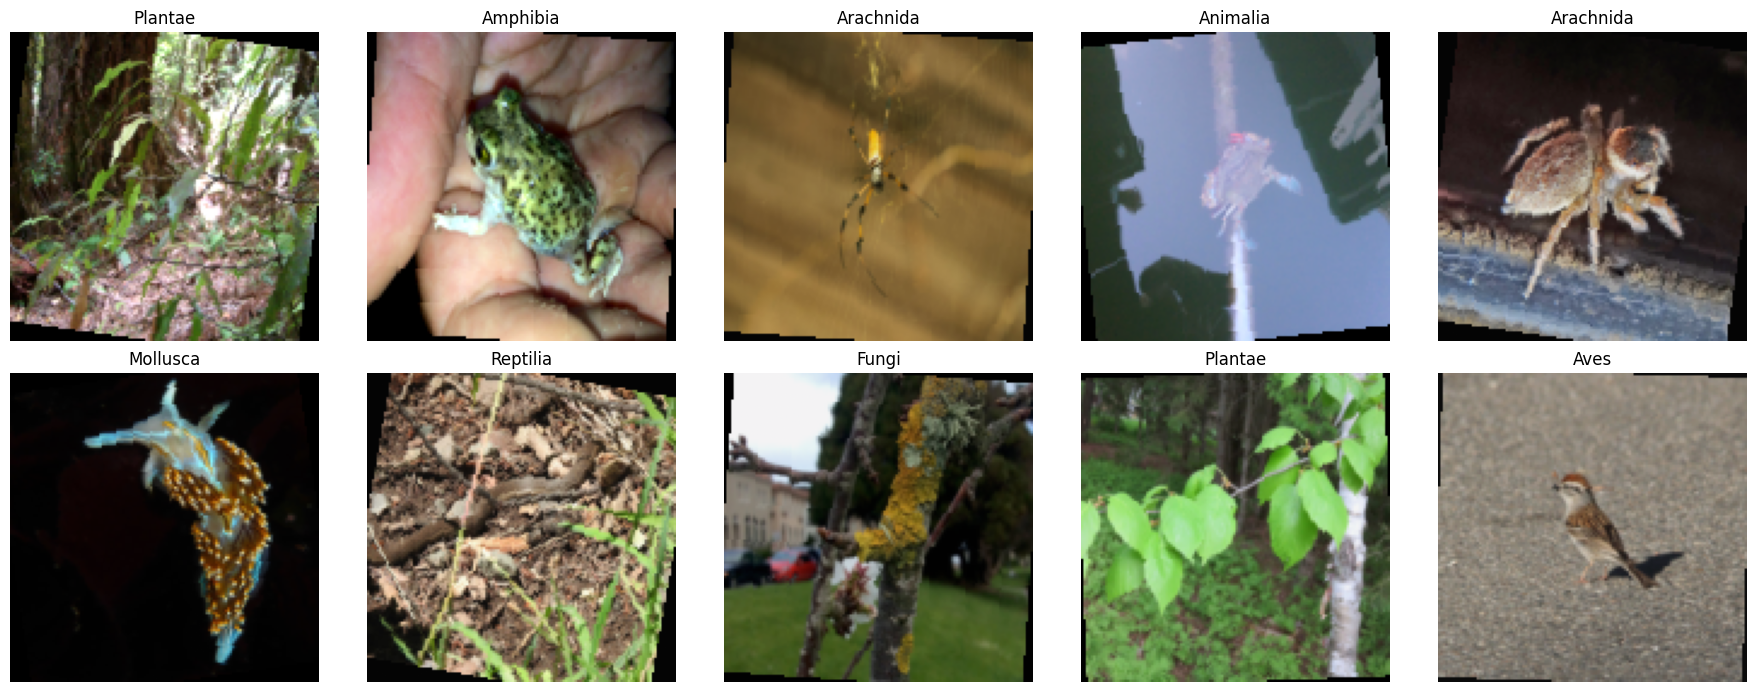

In [4]:
import matplotlib.pyplot as plt

def denormalize(img_tensor, mean, std):
    img = img_tensor.clone()
    for i in range(3):
        img[i] = img[i] * std[i] + mean[i]
    return img.clamp(0, 1)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for i in range(10):
    img, label = train_dataset[i]
    img_display = denormalize(img, mean, std).permute(1, 2, 0).numpy()
    axes[i//5, i%5].imshow(img_display)
    axes[i//5, i%5].set_title(IDX_TO_CLASS[label])
    axes[i//5, i%5].axis('off')
plt.tight_layout()
plt.show()

In [5]:
img, label = train_dataset[0]
print("Min:", img.min().item(), "Max:", img.max().item(), "Mean:", img.mean().item())

Min: -2.032280206680298 Max: 2.640000104904175 Mean: -0.3842330873012543


In [6]:
import hashlib

def file_hash(path):
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

hashes = {}
duplicates = []
for cls_name in CLASS_MAP:
    cls_dir = os.path.join(TRAIN_DIR, cls_name)
    for fname in os.listdir(cls_dir):
        h = file_hash(os.path.join(cls_dir, fname))
        if h in hashes:
            duplicates.append((hashes[h], f"{cls_name}/{fname}"))
        else:
            hashes[h] = f"{cls_name}/{fname}"

print(f"Found {len(duplicates)} exact duplicate images")
print(duplicates[:10])

Found 4 exact duplicate images
[('Amphibia/Amphibia_image_0267.jpg', 'Amphibia/Amphibia_image_0452.jpg'), ('Animalia/Animalia_image_0402.jpg', 'Animalia/Animalia_image_0903.jpg'), ('Arachnida/Arachnida_image_0318.jpg', 'Arachnida/Arachnida_image_0646.jpg'), ('Mollusca/Mollusca_image_0553.jpg', 'Mollusca/Mollusca_image_0382.jpg')]


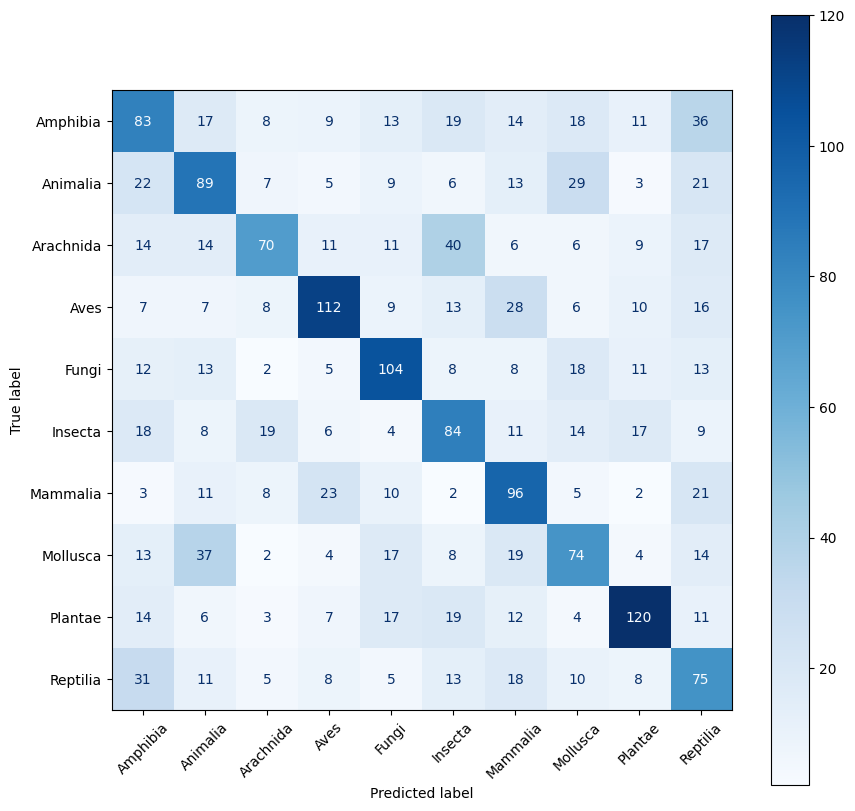

Amphibia: 0.364 (228 samples)
Animalia: 0.436 (204 samples)
Arachnida: 0.354 (198 samples)
Aves: 0.519 (216 samples)
Fungi: 0.536 (194 samples)
Insecta: 0.442 (190 samples)
Mammalia: 0.530 (181 samples)
Mollusca: 0.385 (192 samples)
Plantae: 0.563 (213 samples)
Reptilia: 0.408 (184 samples)


In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.load_state_dict(torch.load("best_model.pth"))
_, _, _, all_preds, all_labels = validate(model, val_loader, criterion, device)

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[IDX_TO_CLASS[i] for i in range(NUM_CLASSES)])
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45, cmap='Blues')
plt.show()

# Print per-class accuracy
for i in range(NUM_CLASSES):
    class_mask = np.array(all_labels) == i
    class_acc = (np.array(all_preds)[class_mask] == i).mean()
    print(f"{IDX_TO_CLASS[i]}: {class_acc:.3f} ({class_mask.sum()} samples)")